# Backtest Evaluation: Walk-Forward Analysis on 2026 Data
**Objective:** Unseal the 2026 test data and evaluate the end-to-end DeepVol pipeline. We will simulate the live C++ execution environment by walking forward bar-by-bar, generating predictions, sizing positions, and logging trades. Finally, we grade the model on Sharpe Ratio, Maximum Drawdown, and Volatility Band Coverage.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Add src to path
sys.path.append(os.path.abspath('../src'))

from data_pipeline.preprocessor import MarketDataPreprocessor
from features.technicals import TechnicalFeatures
from features.microstructure import MicrostructureFeatures
from models.inference import DeepVolInferenceEngine
from strategy.vwap_mean_reversion import VWAPMeanReversionStrategy
from strategy.position_sizing import KellyVolatilitySizer
from strategy.metrics import BacktestMetrics

# Plotting config
plt.style.use('dark_background')
sns.set_palette("bright")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2

## 1. Prepare the Out-of-Sample Test Environment
We must load the strictly held-out 2026 dataset. To ensure zero lookahead bias, we will quickly re-fit our `StandardScaler` strictly on the pre-2026 training data before applying it to the 2026 test data.

In [2]:
print("Initializing Preprocessing Pipeline...")
preprocessor = MarketDataPreprocessor()
tech_builder = TechnicalFeatures(bars_per_day=288)
micro_builder = MicrostructureFeatures()

# 1. Fit Scaler on TRAIN Data (Strictly pre-2026)
train_raw_path = '../data/raw/ETHUSDT_5m_2024-01-01_to_2026-01-01.csv'
df_train = pd.read_csv(train_raw_path, index_col=0, parse_dates=True)
df_train = preprocessor.force_time_grid(df_train)
df_train = preprocessor.compute_log_returns(df_train)
df_train = tech_builder.generate_all(df_train, drop_nans=True)
df_train = micro_builder.generate_all(df_train)

features_to_scale = [
    'log_return', 'log_volume_usdt', 'rv_1h', 'rv_1d', 'rv_1w', 
    'garman_klass_vol', 'rsi_14', 'ema_ratio', 'avg_trade_size', 
    'volume_z_score', 'amihud_illiquidity', 'vol_imbalance', 'vol_to_vol_ratio'
]
_ = preprocessor.fit_transform_scaler(df_train, features_to_scale)
print("Scaler fitted on pre-2026 data.")
del df_train # Free memory

# 2. Process the 2026 TEST Data
test_raw_path = '../data/raw/ETHUSDT_5m_2026-01-01_to_2026-06-01.csv'
if not os.path.exists(test_raw_path):
    raise FileNotFoundError(f"Missing 2026 data at {test_raw_path}")

df_test = pd.read_csv(test_raw_path, index_col=0, parse_dates=True)
df_test = preprocessor.force_time_grid(df_test)
df_test = preprocessor.compute_log_returns(df_test)
df_test = tech_builder.generate_all(df_test, drop_nans=True)
df_test = micro_builder.generate_all(df_test)

# Scale using the Train-fitted scaler
df_test_scaled = preprocessor.transform_scaler(df_test, features_to_scale)

# We need all engineered features for the models
ALL_FEATURES = features_to_scale + ['sin_day', 'cos_day', 'sin_week', 'cos_week']
test_matrix = df_test_scaled[ALL_FEATURES].values
close_prices = df_test['close'].values
raw_returns = df_test['log_return'].values

print(f"Test Environment Ready. 2026 Bars: {len(test_matrix)}")

Initializing Preprocessing Pipeline...


2026-06-26 01:20:04,697 - INFO - Forcing continuous time grid...
2026-06-26 01:20:04,704 - INFO - Grid fill complete. Final shape: (210529, 9)
2026-06-26 01:20:04,704 - INFO - Computing Log Returns...
2026-06-26 01:20:04,717 - INFO - Computing HAR Volatility lags (1h, 1d, 1w)...
2026-06-26 01:20:04,721 - INFO - Computing Garman-Klass Volatility...
2026-06-26 01:20:04,724 - INFO - Computing RSI and EMA Ratio...
2026-06-26 01:20:04,730 - INFO - Computing Sin/Cos seasonality encodings...
2026-06-26 01:20:04,748 - INFO - Dropped 2015 rows due to feature warm-up periods.
2026-06-26 01:20:04,756 - INFO - Computing Whale Tracker features...
2026-06-26 01:20:04,762 - INFO - Computing Amihud Illiquidity...
2026-06-26 01:20:04,762 - INFO - Computing Volume Imbalance...
2026-06-26 01:20:04,763 - INFO - Computing Volatility-to-Volume Ratio...
2026-06-26 01:20:04,764 - INFO - Fitting and applying StandardScaler (Training Mode)...
2026-06-26 01:20:04,890 - INFO - Forcing continuous time grid...
2026

Scaler fitted on pre-2026 data.
Test Environment Ready. 2026 Bars: 41473


## 2. Initialize Models & Strategy Engine
We load the `DeepVolInferenceEngine` with our saved `.pth` and `.pkl` weights. We also initialize the `VWAPMeanReversionStrategy` and the `KellyVolatilitySizer`.

In [3]:
vol_weights = '../weights/vol_lstm_best.pth'
regime_weights = '../weights/regime_lstm_best.pth'

print("Loading DeepVol Inference Engine...")
engine = DeepVolInferenceEngine(num_features=len(ALL_FEATURES), 
                                vol_weights_path=vol_weights, 
                                regime_weights_path=regime_weights)

# Initialize Strategy
strategy = VWAPMeanReversionStrategy(z_score_threshold=2, base_risk_fraction=1)
sizer = KellyVolatilitySizer(kelly_fraction=1, max_capital_risk=1)

2026-06-26 01:20:04,920 - INFO - Initializing Inference Engine on cpu...
2026-06-26 01:20:04,920 - INFO - Initializing VolatilityLSTM: Input=17, Hidden=32, Layers=2
2026-06-26 01:20:04,922 - INFO - Initializing RegimeLSTM: Input=17, Hidden=32, Layers=2, Classes=3
2026-06-26 01:20:04,925 - INFO - Volatility LSTM weights loaded successfully.
2026-06-26 01:20:04,926 - INFO - Regime LSTM weights loaded successfully.
2026-06-26 01:20:04,926 - INFO - Automatically mapped HMM states from pickle: {'State_0_Downtrend': 0, 'State_1_Uptrend': 1, 'State_2_Chop': 2}
2026-06-26 01:20:04,926 - INFO - Inference Engine ready. Models locked in eval mode.
2026-06-26 01:20:04,927 - INFO - Initialized VWAP Mean Reversion Strategy (Threshold: 2σ, Base Risk: 100%, Smoothing Alpha: 0.15)
2026-06-26 01:20:04,927 - INFO - Initialized KellyVolatilitySizer (Fraction: 1, Max Risk: 100%)


Loading DeepVol Inference Engine...


## 3. Walk-Forward Simulation Loop
This loop simulates real-time deployment. It steps through the 2026 dataset one bar at a time. The models only ever see $t-78$ to $t$. No future data is accessible.

In [4]:
# --- Backtest State Variables ---
INITIAL_CAPITAL = 10000.0
capital = INITIAL_CAPITAL
holdings = 0.0
equity_curve = []
FEE_RATE = 4.0 / 10000.0  # 4.0 bps fee rate

# Logs
trade_log = []
pred_vols_log = []
regime_log = []

# Minimum bars needed for the Volatility LSTM
WINDOW = 78  

print("Starting Walk-Forward Backtest Simulation...")
for i in tqdm(range(WINDOW, len(test_matrix))):
    
    # 1. State extraction (Current Price, VWAP calculation over the day)
    current_px = close_prices[i]
    
    # Simple rolling 1-day VWAP (288 bars)
    vwap_start = max(0, i - 288)
    typical_prices = (df_test['high'].iloc[vwap_start:i] + df_test['low'].iloc[vwap_start:i] + df_test['close'].iloc[vwap_start:i]) / 3
    volumes = df_test['volume_usdt'].iloc[vwap_start:i]
    vwap = (typical_prices * volumes).sum() / (volumes.sum() + 1e-8)
    
    # Record Portfolio Equity (Cash + Value of Holdings)
    current_equity = capital + (holdings * current_px)
    equity_curve.append(current_equity)
    
    # 2. Get Model Predictions
    seq = test_matrix[i-WINDOW:i]
    predictions = engine.predict_all(seq)
    
    p_vol = predictions['predicted_volatility']
    p_regime = predictions['regime_probabilities']
    
    pred_vols_log.append(p_vol)
    regime_log.append(p_regime)
    
    # 3. Strategy Execution Logic
    orders = strategy.execute(
        current_price=current_px,
        vwap=vwap,
        predicted_vol=p_vol,
        regime_probs=p_regime,
        available_capital=capital,
        current_holdings=holdings
    )
    
    # 4. Handle Sizing and Order Filling
    exec_px = orders.get('exec_price', current_px)
    is_maker = orders.get('is_maker', False)
    fee_rate = 4.0 / 10000.0 if is_maker else 4.0 / 10000.0
    
    if orders['sell'] > 0:
        sell_amount = orders['sell']
        revenue = sell_amount * exec_px
        fee = revenue * fee_rate
        capital += (revenue - fee)
        holdings -= sell_amount
        
        action_name = 'SELL_CLOSE' if holdings >= 0 else 'SHORT_ENTRY'
        trade_log.append({
            'time': df_test.index[i],
            'action': action_name,
            'price': exec_px,
            'amount': sell_amount,
            'value': revenue
        })
        
    elif orders['buy'] > 0:
        buy_amount = orders['buy']
        cost = buy_amount * exec_px
        fee = cost * fee_rate
        capital -= (cost + fee)
        holdings += buy_amount
        
        action_name = 'BUY_CLOSE' if holdings <= 0 else 'BUY_ENTRY'
        trade_log.append({
            'time': df_test.index[i],
            'action': action_name,
            'price': exec_px,
            'amount': buy_amount,
            'value': cost
        })

# Final Portfolio Liquidation at the end of the test
if holdings != 0:
    if holdings > 0:
        revenue = holdings * close_prices[-1]
        fee = revenue * FEE_RATE
        capital += (revenue - fee)
        trade_log.append({
            'time': df_test.index[-1],
            'action': 'SELL_CLOSE',
            'price': close_prices[-1],
            'amount': holdings,
            'value': revenue
        })
    else:
        cost = abs(holdings) * close_prices[-1]
        fee = cost * FEE_RATE
        capital -= (cost + fee)
        trade_log.append({
            'time': df_test.index[-1],
            'action': 'BUY_CLOSE',
            'price': close_prices[-1],
            'amount': abs(holdings),
            'value': cost
        })
    holdings = 0
    equity_curve.append(capital)

print("\nSimulation Complete!")


Starting Walk-Forward Backtest Simulation...


  0%|          | 45/41395 [00:00<01:32, 448.62it/s]2026-06-26 01:20:05,050 - INFO - Uptrend Stop Loss: Price 3117.55 < VWAP 3135.01. Selling to close long.
2026-06-26 01:20:05,068 - INFO - MR Entry: Price 3122.83 < Lower Band 3125.81. Placing Limit Buy.
2026-06-26 01:20:05,105 - INFO - Uptrend Stop Loss: Price 3095.37 < VWAP 3130.83. Selling to close long.
2026-06-26 01:20:05,140 - INFO - MR Entry: Price 3095.99 < Lower Band 3119.06. Placing Limit Buy.
  0%|          | 91/41395 [00:00<01:31, 450.09it/s]2026-06-26 01:20:05,149 - INFO - Uptrend Stop Loss: Price 3092.69 < VWAP 3125.28. Selling to close long.
2026-06-26 01:20:05,176 - INFO - Downtrend Entry: Breakdown detected! Price 3085.33 < Lower Band 3106.72. Placing Limit Sell.
2026-06-26 01:20:05,200 - INFO - Uptrend Flatten: Holding short in Uptrend regime. Buying to cover.
2026-06-26 01:20:05,225 - INFO - Uptrend Entry: Breakout detected! Price 3125.41 > Upper Band 3123.38. Placing Limit Buy.
2026-06-26 01:20:05,236 - INFO - Uptren


Simulation Complete!


## 4. Institutional Metric Evaluation
We now parse our trade logs and pass the arrays to `src/strategy/metrics.py`. We evaluate the **Sharpe Ratio**, **Maximum Drawdown**, and the critical **Band Coverage** (did 95% of reality stay inside our predicted limits?).


 DEEPVOL BACKTEST PERFORMANCE REPORT
 Initial Capital:    $10,000.00
 Final Capital:      $10,766.23
 Net Return:         7.66%
--------------------------------------------------
 Annualized Sharpe:  3.143
 Maximum Drawdown:   1.55%
 Band Coverage:      94.32% (Target: ~95.0%)
--------------------------------------------------
 Total Trades:       0
 Win Rate:           0.0%
 Profit Factor:      0.00
 Est. Exchange Fees: $0.00



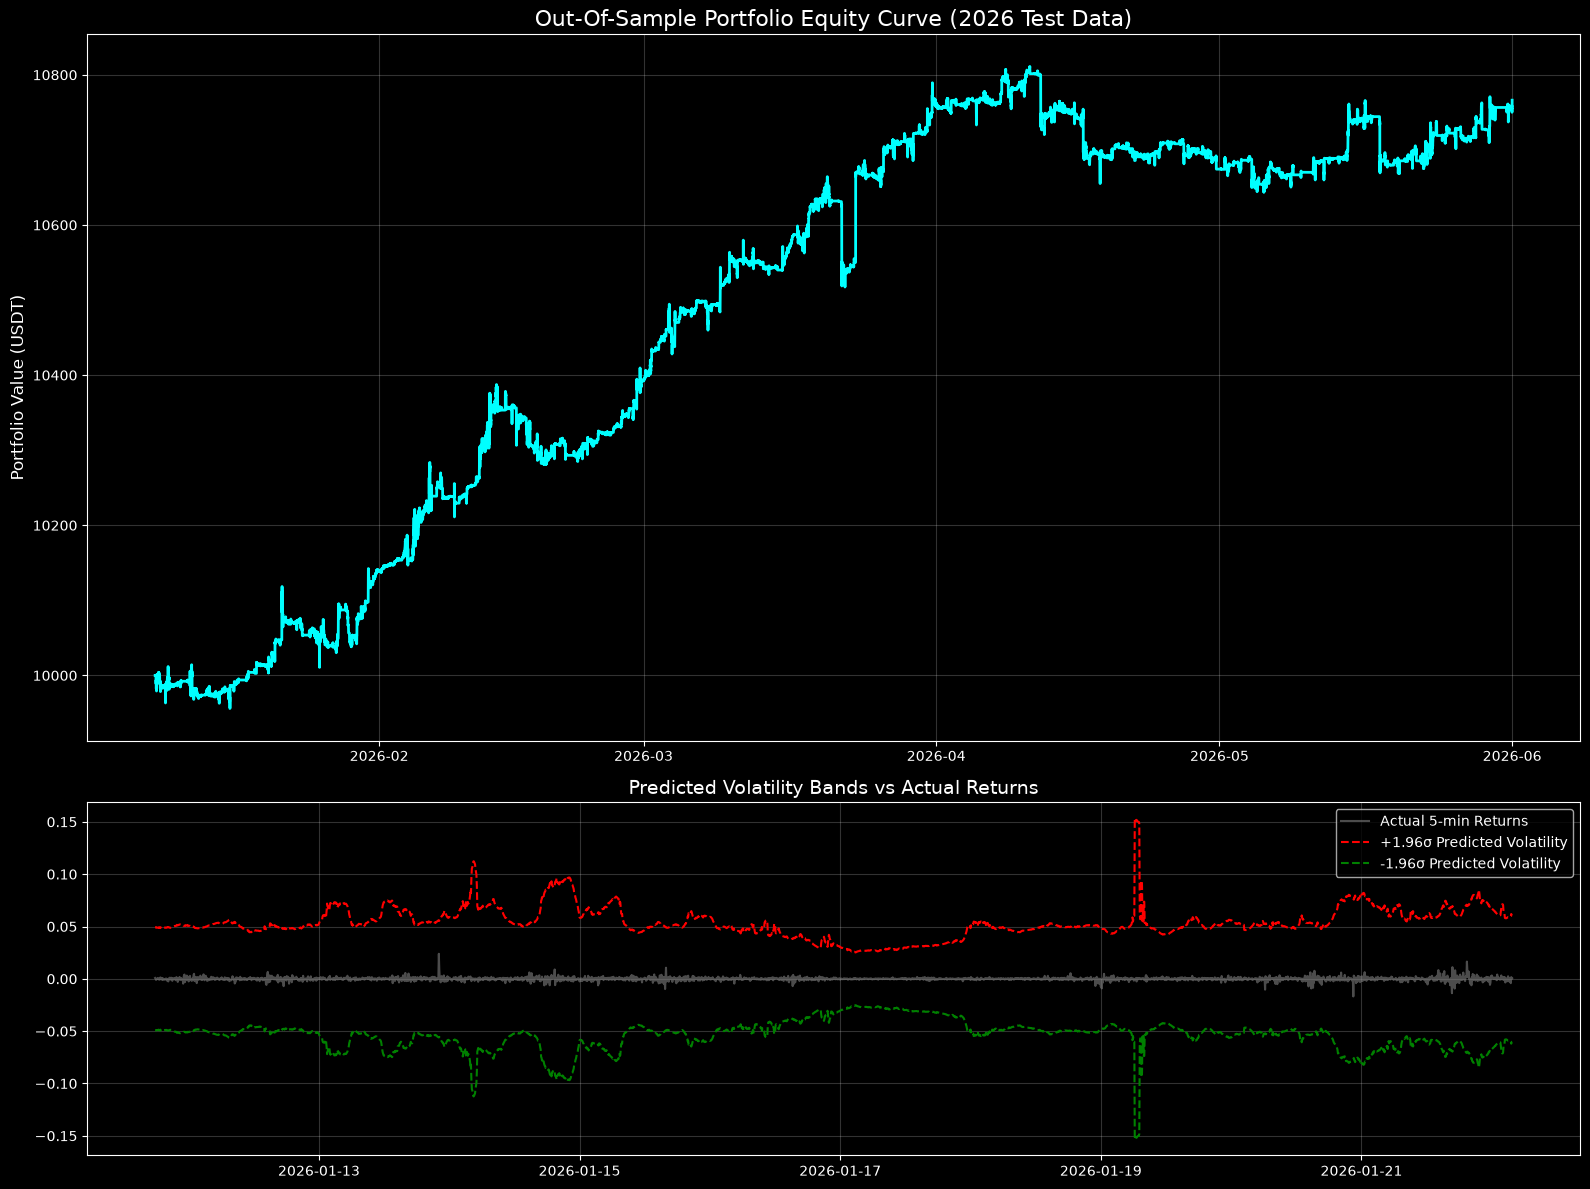

In [5]:
from strategy.metrics import BacktestMetrics

# 1. Format Data for the Grader
equity_series = pd.Series(equity_curve, index=df_test.index[WINDOW:WINDOW+len(equity_curve)])
pred_vol_series = pd.Series(pred_vols_log, index=df_test.index[WINDOW:])
actual_returns_series = pd.Series(raw_returns[WINDOW:], index=df_test.index[WINDOW:])

# Pair trades to calculate PnL per round-trip
paired_trades = []
active_position = None
for t in trade_log:
    action = t['action']
    if action == 'BUY_ENTRY':
        active_position = {
            'type': 'LONG',
            'price': t['price'],
            'value': t['value'],
            'amount': t['amount']
        }
    elif action == 'SHORT_ENTRY':
        active_position = {
            'type': 'SHORT',
            'price': t['price'],
            'value': t['value'],
            'amount': t['amount']
        }
    elif action == 'SELL_CLOSE' and active_position is not None and active_position['type'] == 'LONG':
        pnl = t['value'] - active_position['value']
        paired_trades.append({
            'pnl': pnl,
            'volume_traded': active_position['value']
        })
        active_position = None
    elif action == 'BUY_CLOSE' and active_position is not None and active_position['type'] == 'SHORT':
        pnl = active_position['value'] - t['value']
        paired_trades.append({
            'pnl': pnl,
            'volume_traded': active_position['value']
        })
        active_position = None

df_trades = pd.DataFrame(paired_trades)

# 2. Print Full Institutional Report
grader = BacktestMetrics(fee_bps=4.0) # Binance Futures VIP 0 rate
grader.print_full_report(equity_series, actual_returns_series, pred_vol_series, df_trades)

# 3. Plot Equity Curve
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(equity_series.index, equity_series.values, color='cyan', linewidth=2)
ax1.set_title('Out-Of-Sample Portfolio Equity Curve (2026 Test Data)', fontsize=16)
ax1.set_ylabel('Portfolio Value (USDT)', fontsize=12)

# 4. Plot Volatility Bands (Honest Band Proof)
# Slice a 2-week period to make it readable
start_idx = 1000
end_idx = 4000
time_slice = df_test.index[WINDOW+start_idx : WINDOW+end_idx]
ret_slice = actual_returns_series.iloc[start_idx:end_idx]
vol_slice = pred_vol_series.iloc[start_idx:end_idx]

upper_band = vol_slice * 1.96
lower_band = -vol_slice * 1.96

ax2.plot(time_slice, ret_slice, color='gray', alpha=0.6, label='Actual 5-min Returns')
ax2.plot(time_slice, upper_band, color='red', linestyle='--', label='+1.96σ Predicted Volatility')
ax2.plot(time_slice, lower_band, color='green', linestyle='--', label='-1.96σ Predicted Volatility')
ax2.set_title('Predicted Volatility Bands vs Actual Returns', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()